Create Model to predict song decade

Using Macro F1 as primary metric, along with weighted F1 and Top 3 accuracy 

Also include macro roc auc , macro pr auc, and log loss

In [27]:
import numpy as np
import pandas as pd

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, LabelBinarizer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    f1_score,
    average_precision_score,
    roc_auc_score,
    top_k_accuracy_score,
    log_loss
)

from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

Read in the data for decade

In [29]:
X_train = pd.read_csv('data/decade_scaled_X_train.csv')
X_test = pd.read_csv('data/decade_scaled_X_test.csv')
y_train = pd.read_csv('data/decade_y_train.csv')
y_test = pd.read_csv('data/decade_y_test.csv')

In [30]:
np.sort(np.unique(y_test))

array([1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020])

Label encode decade

In [31]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

c:\Users\627700\Documents\Music2\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\627700\Documents\Music2\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [32]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7])

In [33]:
np.unique(y_test)

array([0, 1, 2, 3, 4, 5, 6, 7])

In [ ]:
def evaluate_model(y_true, y_prob):

    total_classes = y_prob.shape[1]

    # Derive class predictions from highest probability
    y_pred = y_prob.argmax(axis=1)
    
    # Binarize true labels for multiclass PR-AUC calculations
    lb = LabelBinarizer()
    lb.fit(range(total_classes))  # Ensure all classes are considered
    y_true_binarized = lb.transform(y_true)
    
    # Calculate metrics
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    macro_prauc = average_precision_score(
        y_true_binarized,
        y_prob,
        average='macro'
    )

    try:
        macro_rocauc = roc_auc_score(
            y_true,
            y_prob,
            multi_class='ovr',
            average='macro'
        )
    except ValueError:
        macro_rocauc = np.nan

    top_3_acc = top_k_accuracy_score(y_true, y_prob, k=3, labels=range(total_classes))
    logloss = log_loss(y_true, y_prob, labels=range(total_classes))

    # adjacent decade accuracy, within one decade
    adjacent_accuracy = np.mean(np.abs(y_true - y_pred) <= 1)

    mae_decades = np.mean(np.abs(y_true - y_pred))
    
    # Return as dictionary
    return {
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "Macro PR-AUC": macro_prauc,
        "Macro ROC AUC": macro_rocauc,
        "Top-3 Accuracy": top_3_acc,
        "Log-Loss": logloss,
        "Adjacent Accuracy" : adjacent_accuracy,
        "Mean Average Error" : mae_decades
    }

In [ ]:
# Compute sample weights dynamically
sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

# All models configured to address the class imbalance
models = {
    "Random Forest": RandomForestClassifier(
        class_weight='balanced_subsample', 
        n_jobs=-1, 
        random_state=42
    ),
    
    "LightGBM": lgb.LGBMClassifier(
        objective='multiclass',
        num_class=len(set(y_train)) ,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    
    "XGBoost": XGBClassifier(
        objective='multi:softprob', 
        num_class=len(set(y_train)) , 
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    ),
    
    "CatBoost": CatBoostClassifier(
        loss_function='MultiClass', 
        auto_class_weights='Balanced',
        random_state=42,
        verbose=50  
    )
}

performance_results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    # separate out each model so can view results later
    
    if name == "XGBoost":
        xgb_model = model
        xgb_model.fit(X_train, y_train, sample_weight=sample_weights_train)

    elif name == "LightGBM":
        lgb_model = model
        lgb_model.fit(
            X_train, y_train,
            sample_weight=sample_weights_train, 
            eval_set=[(X_test, y_test)],
            eval_metric="multi_logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)] 
        )

    elif name == "CatBoost":
        catboost_model = model
        catboost_model.fit(X_train, y_train)

    else:
        rf_model = model
        rf_model.fit(X_train, y_train)


    print(f"Evaluating {name} on validation data...")
    if name == "CatBoost":
        y_prob_test = catboost_model.predict_proba(X_test)
    elif name == "LightGBM":
        y_prob_test = lgb_model.predict_proba(X_test)
    elif name == "XGBoost":
        y_prob_test = xgb_model.predict_proba(X_test)
    else:
        y_prob_test = rf_model.predict_proba(X_test)

    
    # Execute the evaluation function
    metrics = evaluate_model(y_test, y_prob_test)
    performance_results[name] = metrics

print("\n" + "="*50)
print("FINAL MODEL COMPARISON RESULTS")
print("="*50)

# Convert results dict to a DataFrame
df_results = pd.DataFrame(performance_results).T
print(df_results.to_string(formatters={c: '{:,.4f}'.format for c in df_results.columns}))


Training Random Forest...
Evaluating Random Forest on validation data...

Training LightGBM...
Evaluating LightGBM on validation data...

Training XGBoost...
Evaluating XGBoost on validation data...

Training CatBoost...
Learning rate set to 0.121125
0:	learn: 2.0428258	total: 729ms	remaining: 12m 8s
50:	learn: 1.7818171	total: 31s	remaining: 9m 37s
100:	learn: 1.7437588	total: 59.5s	remaining: 8m 49s
150:	learn: 1.7207402	total: 1m 28s	remaining: 8m 17s
200:	learn: 1.7035689	total: 1m 58s	remaining: 7m 49s
250:	learn: 1.6922405	total: 2m 25s	remaining: 7m 14s
300:	learn: 1.6829094	total: 2m 55s	remaining: 6m 47s
350:	learn: 1.6747125	total: 3m 28s	remaining: 6m 25s
400:	learn: 1.6682552	total: 4m 1s	remaining: 6m
450:	learn: 1.6625831	total: 4m 30s	remaining: 5m 29s
500:	learn: 1.6573164	total: 4m 58s	remaining: 4m 57s
550:	learn: 1.6524794	total: 5m 26s	remaining: 4m 25s
600:	learn: 1.6480952	total: 5m 55s	remaining: 3m 55s
650:	learn: 1.6437682	total: 6m 23s	remaining: 3m 25s
700:	

My results suggest that Random Forest is usually close, but often misses the exact decade. While, CatBoost gets the exact decade slightly more often but makes larger mistakes when it's wrong.
RF predicts correct decade or neighboring decade 80% of time, while boost models don't. 

In [36]:
catboost_model.classes_

array([0, 1, 2, 3, 4, 5, 6, 7])

In [37]:
lgb_model.classes_

array([0, 1, 2, 3, 4, 5, 6, 7])

In [38]:
xgb_model.classes_

array([0, 1, 2, 3, 4, 5, 6, 7])

In [40]:
rf_model.classes_

array([0, 1, 2, 3, 4, 5, 6, 7])

In [ ]:
# ==================================================
# FINAL MODEL COMPARISON RESULTS
# ==================================================
#               Macro F1 Weighted F1 Macro PR-AUC Macro ROC AUC Top-3 Accuracy Log-Loss Adjacent Accuracy Mean Average Error
# Random Forest   0.1566      0.3638       0.2208        0.7369         0.8522   1.5147            0.8078             0.8602
# LightGBM        0.1884      0.2564       0.2118        0.7385         0.6809   1.7815            0.5854             1.7374
# XGBoost         0.1928      0.2621       0.2161        0.7439         0.6875   1.7632            0.5938             1.7050
# CatBoost        0.1973      0.2631       0.2201        0.7488         0.6983   1.7489            0.6026             1.6565


View confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix

y_t = y_test
y_p = catboost_model.predict(X_test)

matrix = confusion_matrix(y_t, y_p.ravel())

# Define class labels in order
class_labels = [1950,1960,1970,1980,1990,2000,2010,2020] 

matrix_df = pd.DataFrame(
    matrix, 
    index=[f"Actual {label}" for label in class_labels], 
    columns=[f"Predicted {label}" for label in class_labels]
)

matrix_df

,Predicted 1950,Predicted 1960,Predicted 1970,Predicted 1980,Predicted 1990,Predicted 2000,Predicted 2010,Predicted 2020
Actual 1950,3097,824,398,275,187,90,36,72
Actual 1960,4073,6183,2758,1151,503,547,290,283
Actual 1970,4284,5582,9547,4357,1490,1458,743,1038
Actual 1980,6400,4784,8513,17438,4990,3090,2172,3144
Actual 1990,22374,14464,17438,28721,22018,19908,12364,19143
Actual 2000,24997,19842,22748,27751,25747,58163,40687,51610
Actual 2010,21695,20912,25053,32468,26629,61478,93464,159004
Actual 2020,3447,3050,3839,4656,4230,8424,14908,44823


Save to data/

In [44]:
matrix_df.to_csv('data/decade_rf_confusion_matrix.csv', index=True)

In [46]:
matrix_df.to_csv('data/decade_catboost_confusion_matrix.csv', index=True)

Confusion matrix for random forest model

In [ ]:
y_pred = rf_model.predict(X_test)

cm_norm = confusion_matrix(
    y_test,
    y_pred,
    normalize='true'
)

<Axes: >

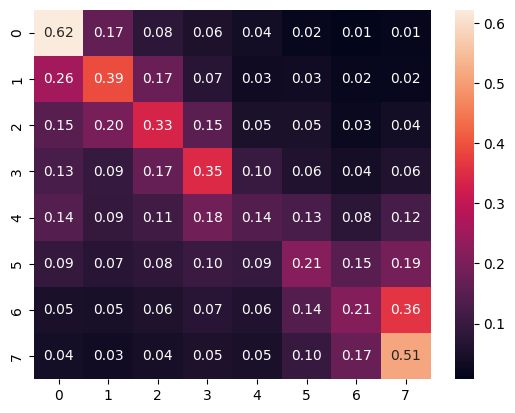

In [23]:
import seaborn as sns
sns.heatmap(cm_norm, annot=True, fmt=".2f")

Calculate Feature Importance for Catboost and Random Forest

In [ ]:
#importances = catboost_model.get_feature_importance()
importances = rf_model.feature_importances_

# Map to feature names and sort
fi_df = pd.DataFrame({
    'feature_names': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(fi_df)

                         feature_names  importance
8      tuning_equal_tempered_deviation    0.083479
6                       mfcc_zero_mean    0.082299
4                     average_loudness    0.079506
3                           onset_rate    0.079463
2                         danceability    0.079367
5                   dynamic_complexity    0.077472
10                     mood_happy_prob    0.074452
0                                  bpm    0.073208
11                mood_aggressive_prob    0.071145
7                     tuning_frequency    0.067540
1   bpm_histogram_second_peak_bpm_mean    0.060141
19                        voice_gender    0.011410
9                            key_scale    0.010803
22                  voice_instrumental    0.010061
17                     mood_electronic    0.009869
20                              timbre    0.009653
21                        tonal_atonal    0.009209
12                          mood_happy    0.009166
26                           ke

In [ ]:
#                          feature_names  importance
# 7                     tuning_frequency   14.280711
# 6                       mfcc_zero_mean   10.440724
# 8      tuning_equal_tempered_deviation    8.854942
# 3                           onset_rate    7.830003
# 4                     average_loudness    6.805222
# 2                         danceability    6.758167
# 0                                  bpm    6.240841
# 5                   dynamic_complexity    5.078026
# 11                mood_aggressive_prob    3.819207
# 12                          mood_happy    3.285772
# 17                     mood_electronic    3.233978
# 10                     mood_happy_prob    2.834837
# 22                  voice_instrumental    2.568288
# 20                              timbre    2.378720
# 16                       mood_acoustic    2.249951
# 1   bpm_histogram_second_peak_bpm_mean    1.998226
# 21                        tonal_atonal    1.438601
# 15                     mood_aggressive    1.389520
# 19                        voice_gender    1.122085
# 13                            mood_sad    1.025784
# 14                        mood_relaxed    0.871421
# 9                            key_scale    0.722304
# 18                          mood_party    0.666261
# 23                           key_key_A    0.657583
# 24                          key_key_A#    0.542825
# 30                           key_key_E    0.491141
# 28                           key_key_D    0.456287
# 29                          key_key_D#    0.313023
# 34                          key_key_G#    0.305119
# 31                           key_key_F    0.300343
# 26                           key_key_C    0.292927
# 33                           key_key_G    0.260354
# 25                           key_key_B    0.211006
# 27                          key_key_C#    0.151410
# 32                          key_key_F#    0.124390